<a href="https://colab.research.google.com/github/Kishanmvs/Data-Mining-Project/blob/main/Module_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BCI606 — Data Mining Mini Project
## Module 5: Clustering & Anomaly Detection
### Domain: Global Space Exploration Analytics

**Algorithms covered:** k-Means · Hierarchical (Agglomerative/Ward) · DBSCAN  
**Dimensionality reduction:** PCA · t-SNE  
**Dataset:** `Global_Space_Exploration_Dataset.csv` (3 000 missions, 12 features)

---
> **Workflow:**  
> `Step 0` Load raw data → `Step 1` Preprocess → `Step 2` Dim-reduction →  
> `Step 3` k-Means (Elbow + Silhouette) → `Step 4` Hierarchical → `Step 5` DBSCAN →  
> `Step 6` Visualise → `Step 7` Summary comparison


## Step 0 — Imports & Environment Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder, StandardScaler

from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib.patches import Patch

import warnings, time, os
warnings.filterwarnings('ignore')

os.makedirs("datasets", exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
print("All libraries loaded ✓")


All libraries loaded ✓


## Step 1 — Load & Preprocess the Raw Dataset

The `.py` module expects `datasets/preprocessed_full.csv` (output of a separate  
`module2_preprocessing.py`). This notebook reproduces that preprocessing inline so  
the entire pipeline is self-contained.

**Engineering decisions**
| Column | Treatment |
|---|---|
| `Success Rate (%)` | Binarised → `is_high_success` (≥ 70 = 1) |
| `Mission Type` | Label-encoded (Manned=1, Unmanned=0) |
| `Technology Used` | One-hot encoded |
| `Environmental Impact` | Ordinal mapped (Low=0, Medium=1, High=2) |
| `Collaborating Countries` | Parsed → `collab_count` (integer) |
| `mission_era` | Year bucketed into 5-year eras (ordinal int) |
| `Country`, `Satellite Type`, `Launch Site` | Label-encoded |
| All numerics | StandardScaler |


In [ ]:
RAW_PATH = "Global_Space_Exploration_Dataset.csv"  # adjust if needed

df_raw = pd.read_csv(RAW_PATH)
print(f"Raw shape: {df_raw.shape}")
df_raw.head(3)


Raw shape: (3000, 12)


,Country,Year,Mission Name,Mission Type,Launch Site,Satellite Type,Budget (in Billion $),Success Rate (%),Technology Used,Environmental Impact,Collaborating Countries,Duration (in Days)
0,China,2008,Sharable tertiary superstructure,Manned,Sheilatown,Communication,16.20,90,Nuclear Propulsion,Medium,"France, UK, Russia",112
1,Japan,2018,Re-engineered composite flexibility,Manned,New Ericfurt,Communication,29.04,99,Solar Propulsion,High,"Germany, Israel",236
2,Israel,2013,Reactive disintermediate projection,Manned,Port Kaitlynstad,Communication,28.73,54,AI Navigation,Medium,"China, Israel, USA",238


In [ ]:
df = df_raw.copy()

# ── Target variable ────────────────────────────────────────────────────────────
df['is_high_success'] = (df['Success Rate (%)'] >= 70).astype(int)
print(f"High-success missions: {df['is_high_success'].mean()*100:.1f}%")

# ── Collaborating Countries → count ───────────────────────────────────────────
df['collab_count'] = (
    df['Collaborating Countries']
    .fillna('')
    .apply(lambda x: len([c for c in x.split(',') if c.strip()]))
)

# ── Mission era (5-year buckets) ───────────────────────────────────────────────
df['mission_era'] = ((df['Year'] - df['Year'].min()) // 5).astype(int)

# ── Ordinal encoding ───────────────────────────────────────────────────────────
env_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['Environmental Impact'] = df['Environmental Impact'].map(env_map)

# ── Label encoding ─────────────────────────────────────────────────────────────
le = LabelEncoder()
for col in ['Mission Type', 'Country', 'Satellite Type']:
    df[col] = le.fit_transform(df[col].astype(str))

# ── One-hot: Technology Used ───────────────────────────────────────────────────
tech_dummies = pd.get_dummies(df['Technology Used'], prefix='tech')
df = pd.concat([df, tech_dummies], axis=1)

# ── Drop columns not used for clustering ──────────────────────────────────────
drop_cols = ['Mission Name', 'Year', 'Launch Site', 'Success Rate (%)',
             'Technology Used', 'Collaborating Countries']
df.drop(columns=drop_cols, inplace=True)

# ── Separate target then scale features ───────────────────────────────────────
y_true = df['is_high_success'].values
X_raw  = df.drop(columns=['is_high_success'])

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=X_raw.columns)

# ── Save preprocessed file (for compatibility with standalone .py module) ──────
full_out = X_scaled.copy()
full_out['is_high_success'] = y_true
full_out.to_csv("datasets/preprocessed_full.csv", index=False)
print(f"Preprocessed shape: {full_out.shape}")
print(f"Features: {X_scaled.columns.tolist()}")


High-success missions: 60.1%
Preprocessed shape: (3000, 14)
Features: ['Country', 'Mission Type', 'Satellite Type', 'Budget (in Billion $)', 'Environmental Impact', 'Duration (in Days)', 'collab_count', 'mission_era', 'tech_AI Navigation', 'tech_Nuclear Propulsion', 'tech_Reusable Rocket', 'tech_Solar Propulsion', 'tech_Traditional Rocket']


## Step 2 — Load Preprocessed Data (as the .py Module Does)

In [ ]:
df_proc = pd.read_csv("datasets/preprocessed_full.csv")
y_true  = df_proc['is_high_success'].values
X       = df_proc.drop(columns=['is_high_success'])

X_cluster = X.copy()
y_cluster = y_true.copy()

print(f"Clustering on: {X_cluster.shape[0]:,} missions, {X_cluster.shape[1]} features")
print(f"High-success rate: {y_cluster.mean()*100:.1f}%")


Clustering on: 3,000 missions, 13 features
High-success rate: 60.1%


## Step 3 — Dimensionality Reduction: PCA + t-SNE

**PCA (Principal Component Analysis)**  
Linear projection that captures the directions of maximum variance.  
`PC1` and `PC2` together explain what % of the total variance is preserved in 2D.

**t-SNE (t-distributed Stochastic Neighbour Embedding)**  
Non-linear, preserves local neighbourhood structure.  
Better at revealing cluster separability visually, but slower and stochastic.  
`perplexity` controls the effective number of neighbours (30 is typical).


In [ ]:
# PCA
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)
print(f"PCA total explained variance : {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  PC1 : {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2 : {pca.explained_variance_ratio_[1]*100:.1f}%")

# t-SNE (may take 1-2 min on 3 000 points)
print("\nRunning t-SNE …")
start  = time.time()
tsne   = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_cluster)
print(f"t-SNE done in {time.time()-start:.1f}s")


PCA total explained variance : 19.7%
  PC1 : 9.9%
  PC2 : 9.7%

Running t-SNE …
t-SNE done in 16.1s


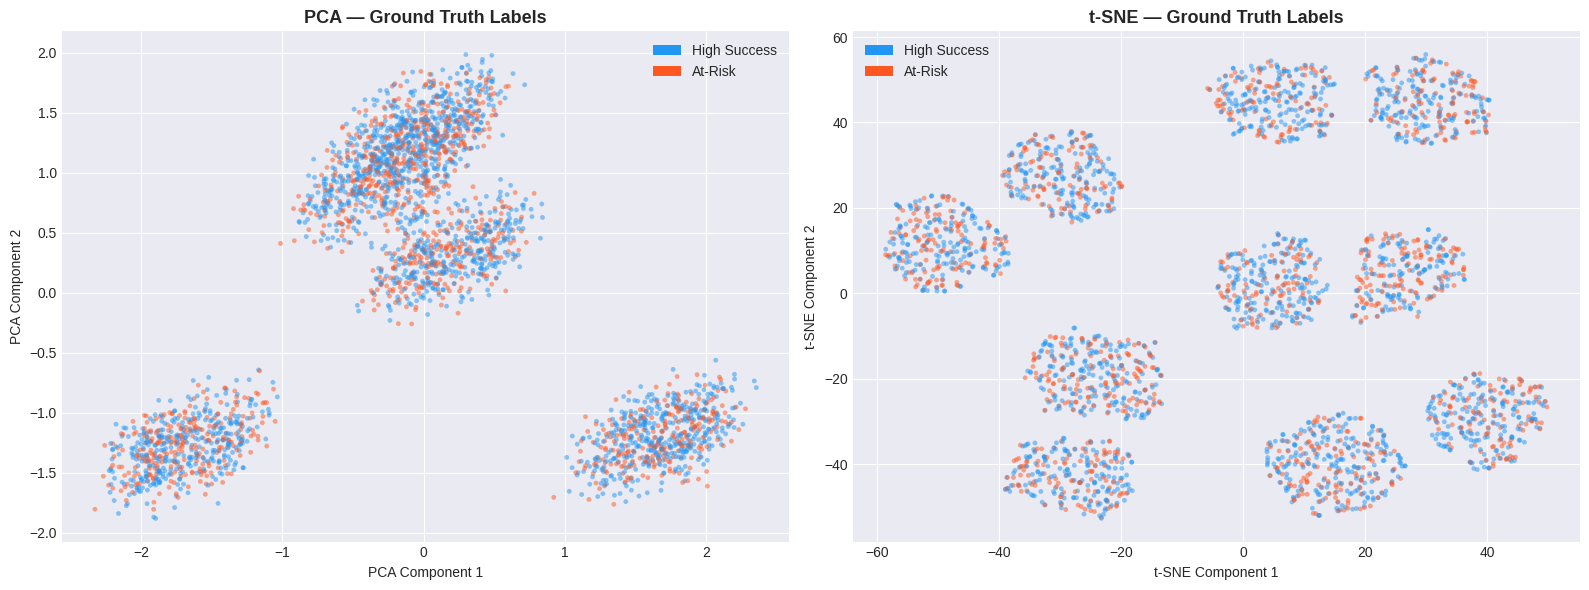

Saved → datasets/clustering_ground_truth.png


In [ ]:
# Ground-truth overlay (is_high_success)
cmap   = {1: '#2196F3', 0: '#FF5722'}
colors = [cmap[y] for y in y_cluster]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, X_emb, title in [(axes[0], X_pca, 'PCA'), (axes[1], X_tsne, 't-SNE')]:
    ax.scatter(X_emb[:, 0], X_emb[:, 1], c=colors, alpha=0.5, s=12, edgecolors='none')
    ax.set_title(f'{title} — Ground Truth Labels', fontsize=13, fontweight='bold')
    ax.set_xlabel(f'{title} Component 1')
    ax.set_ylabel(f'{title} Component 2')
    legend_elements = [Patch(facecolor='#2196F3', label='High Success'),
                       Patch(facecolor='#FF5722', label='At-Risk')]
    ax.legend(handles=legend_elements)

fig.tight_layout()
fig.savefig('datasets/clustering_ground_truth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → datasets/clustering_ground_truth.png")


## Step 4 — k-Means Clustering

**Algorithm (Lloyd's):**
1. Initialise `k` centroids with k-Means++ seeding  
2. Assign each point to its nearest centroid  
3. Update centroids as the mean of assigned points  
4. Repeat until convergence

**Inertia (WCSS):** $J = \sum_i \|x_i - \mu_{c(i)}\|^2$ — lower is better  
**Elbow Method:** find the `k` where the inertia curve "elbows"  
**Silhouette Score:** $S(i) = \frac{b(i)-a(i)}{\max(a(i),b(i))} \in [-1,1]$ — higher is better


In [ ]:
k_range    = range(2, 11)
inertias   = []
silhouettes = []

print("Elbow search (k = 2 … 10):")
for k in k_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    lbl = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_cluster, lbl, sample_size=min(1000, len(X_cluster)))
    silhouettes.append(sil)
    print(f"  k={k:2d}: Inertia={km.inertia_:>12,.0f}   Silhouette={sil:.4f}")


Elbow search (k = 2 … 10):
  k= 2: Inertia=      35,183   Silhouette=0.0993
  k= 3: Inertia=      31,444   Silhouette=0.1523
  k= 4: Inertia=      27,686   Silhouette=0.2025
  k= 5: Inertia=      23,962   Silhouette=0.2578
  k= 6: Inertia=      23,314   Silhouette=0.2064
  k= 7: Inertia=      22,741   Silhouette=0.1882
  k= 8: Inertia=      22,157   Silhouette=0.1714
  k= 9: Inertia=      21,843   Silhouette=0.1288
  k=10: Inertia=      21,382   Silhouette=0.1081


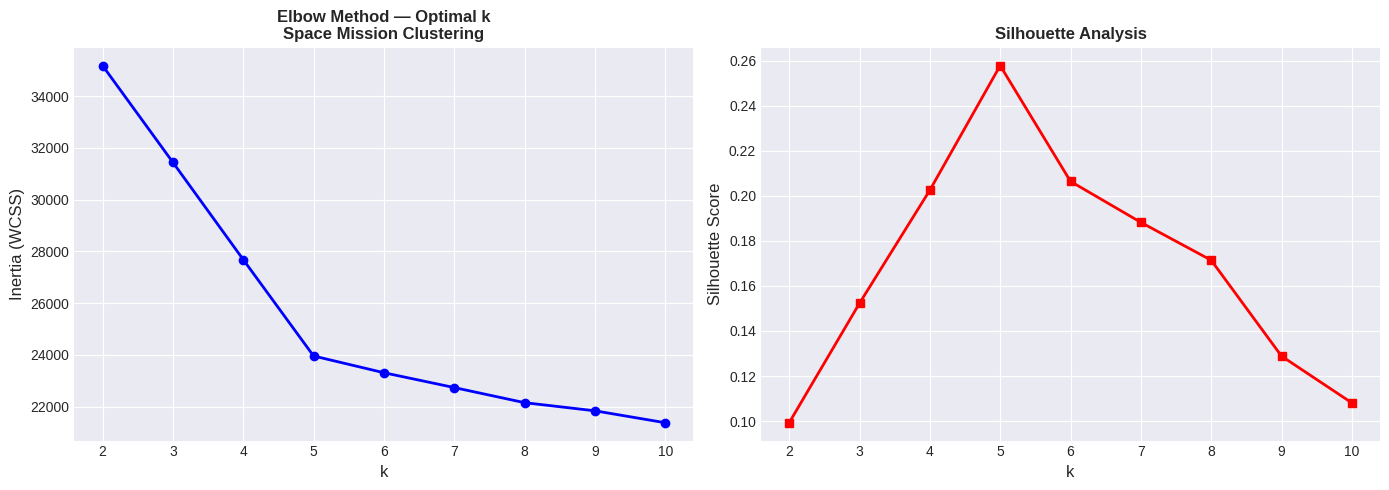

Saved → datasets/clustering_elbow_silhouette.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('k', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method — Optimal k\nSpace Mission Clustering', fontweight='bold')

axes[1].plot(list(k_range), silhouettes, 'rs-', linewidth=2)
axes[1].set_xlabel('k', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontweight='bold')

fig.tight_layout()
fig.savefig('datasets/clustering_elbow_silhouette.png', dpi=150)
plt.show()
print("Saved → datasets/clustering_elbow_silhouette.png")


In [ ]:
OPTIMAL_K = 3   # three mission archetypes: Budget-Constrained / Mid-Range / High-Tech

kmeans    = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_cluster)

km_sil = silhouette_score(X_cluster, km_labels, sample_size=min(1000, len(X_cluster)))
km_ari = adjusted_rand_score(y_cluster, km_labels)
print(f"k-Means (k={OPTIMAL_K}) — Silhouette: {km_sil:.4f}   ARI: {km_ari:.4f}")

# Cross-tabulation: cluster vs outcome
ct_km = pd.crosstab(km_labels, y_cluster,
                    rownames=['Cluster'], colnames=['is_high_success'])
ct_km.columns = ['At-Risk', 'High Success']
ct_km['High_Success_%'] = (ct_km['High Success'] /
                            ct_km.sum(axis=1) * 100).round(2)
print("\nCluster × Outcome:")
display(ct_km)

# Cluster centroids for interpretable features
numeric_feats = ['Budget (in Billion $)', 'Duration (in Days)',
                 'collab_count', 'Environmental Impact',
                 'Mission Type', 'mission_era']
available = [f for f in numeric_feats if f in X_cluster.columns]
if available:
    print("\nCluster centroids (selected features):")
    X_lab = X_cluster.copy()
    X_lab['cluster'] = km_labels
    display(X_lab.groupby('cluster')[available].mean().round(3))


k-Means (k=3) — Silhouette: 0.1577   ARI: -0.0005

Cluster × Outcome:


,At-Risk,High Success,High_Success_%
Cluster,,,
0,251,399,61.38
1,457,722,61.24
2,490,681,58.16



Cluster centroids (selected features):


,Budget (in Billion $),Duration (in Days),collab_count,Environmental Impact,Mission Type,mission_era
cluster,,,,,,
0,0.010,-0.052,0.009,0.035,-0.074,0.009
1,0.000,0.018,-0.003,-0.025,-0.008,0.031
2,-0.006,0.011,-0.002,0.006,0.049,-0.036


## Step 5 — Hierarchical (Agglomerative) Clustering

**Ward linkage** merges the pair of clusters that minimises the increase in total  
within-cluster variance — tends to produce compact clusters of similar size.

The **dendrogram** is computed on a 500-point subsample (the full 3 000 would be  
unreadable). The y-axis (Ward distance / merge cost) indicates how dissimilar  
two groups are when merged; large jumps signal meaningful boundaries.


Computing Ward linkage on 500 sampled missions …
Done in 0.0s


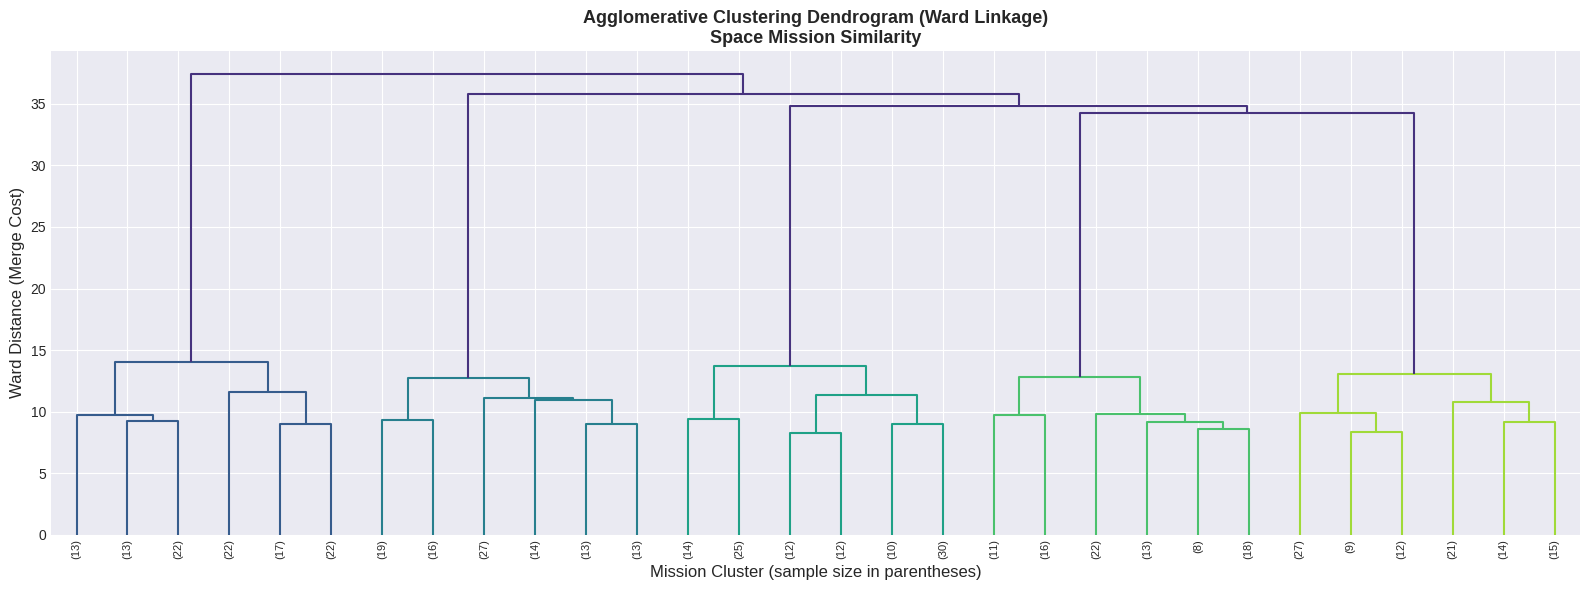

Saved → datasets/clustering_dendrogram.png


In [ ]:
# Dendrogram on subsample
DENDRO_N = 500
np.random.seed(42)
idx_d   = np.random.choice(len(X_cluster), DENDRO_N, replace=False)
X_dendro = X_cluster.iloc[idx_d]

print(f"Computing Ward linkage on {DENDRO_N} sampled missions …")
t0 = time.time()
Z  = linkage(X_dendro, method='ward')
print(f"Done in {time.time()-t0:.1f}s")

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(Z, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=8,
           ax=ax, color_threshold=0.7 * max(Z[:, 2]))
ax.set_title('Agglomerative Clustering Dendrogram (Ward Linkage)\nSpace Mission Similarity',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mission Cluster (sample size in parentheses)', fontsize=12)
ax.set_ylabel('Ward Distance (Merge Cost)', fontsize=12)
fig.tight_layout()
fig.savefig('datasets/clustering_dendrogram.png', dpi=150)
plt.show()
print("Saved → datasets/clustering_dendrogram.png")


In [ ]:
print(f"Fitting Agglomerative Clustering (n_clusters={OPTIMAL_K}) on full dataset …")
t0 = time.time()
agg       = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
agg_labels = agg.fit_predict(X_cluster)
print(f"Done in {time.time()-t0:.1f}s")

agg_sil = silhouette_score(X_cluster, agg_labels, sample_size=min(1000, len(X_cluster)))
agg_ari = adjusted_rand_score(y_cluster, agg_labels)
print(f"Hierarchical (Ward) — Silhouette: {agg_sil:.4f}   ARI: {agg_ari:.4f}")

ct_agg = pd.crosstab(agg_labels, y_cluster,
                     rownames=['Cluster'], colnames=['is_high_success'])
ct_agg.columns = ['At-Risk', 'High Success']
ct_agg['High_Success_%'] = (ct_agg['High Success'] /
                             ct_agg.sum(axis=1) * 100).round(2)
print("\nCluster × Outcome:")
display(ct_agg)


Fitting Agglomerative Clustering (n_clusters=3) on full dataset …
Done in 0.2s
Hierarchical (Ward) — Silhouette: 0.1567   ARI: 0.0008

Cluster × Outcome:


,At-Risk,High Success,High_Success_%
Cluster,,,
0,691,1050,60.31
1,251,399,61.38
2,256,353,57.96


## Step 6 — DBSCAN Clustering & Anomaly Detection

**Three point types:**
| Type | Definition |
|---|---|
| **Core** | ≥ `min_samples` neighbours within `eps` radius |
| **Border** | within `eps` of a core point, but < `min_samples` neighbours itself |
| **Noise / Outlier** | label `−1` — no core point within `eps` |

**Why DBSCAN matters for space missions:**  
k-Means forces *every* mission into a cluster, hiding genuine outliers.  
DBSCAN explicitly surfaces missions with **no historical precedent** —  
unusual budget × duration × technology combinations that warrant special review.

**Parameter selection:**  
- `eps`: estimated from the *k-distance graph* — sort missions by their  
  distance to the *k*th nearest neighbour; the "knee" is a good `eps`.  
- `min_samples`: rule of thumb ≈ 2 × n_features; we use 15 here.


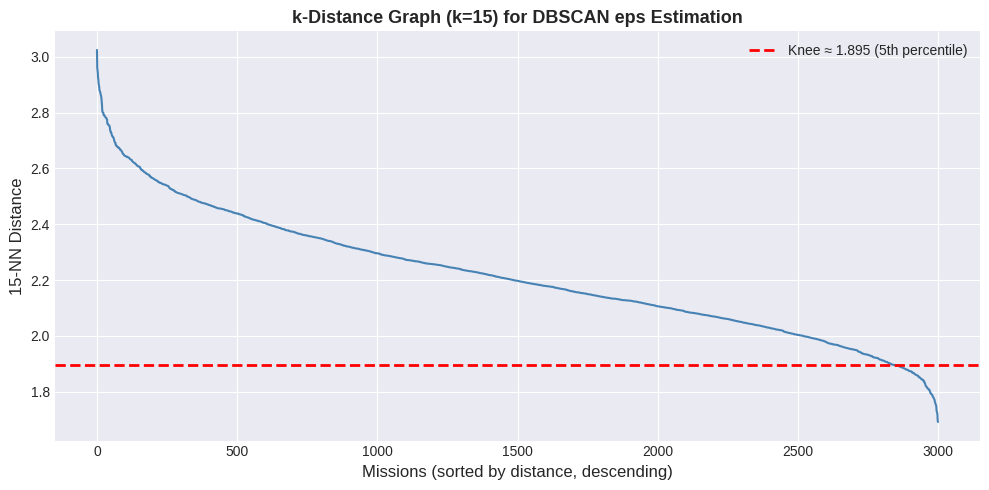

Estimated eps = 1.895
Saved → datasets/clustering_kdistance.png


In [ ]:
K_DIST = 15
nn     = NearestNeighbors(n_neighbors=K_DIST, n_jobs=-1)
nn.fit(X_cluster)
dists, _ = nn.kneighbors(X_cluster)
k_distances = np.sort(dists[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(k_distances)), k_distances, linewidth=1.5, color='steelblue')
ax.set_xlabel('Missions (sorted by distance, descending)', fontsize=12)
ax.set_ylabel(f'{K_DIST}-NN Distance', fontsize=12)
ax.set_title(f'k-Distance Graph (k={K_DIST}) for DBSCAN eps Estimation',
             fontsize=13, fontweight='bold')

knee_eps = np.percentile(k_distances, 5)
ax.axhline(y=knee_eps, color='red', linestyle='--', linewidth=2,
           label=f'Knee ≈ {knee_eps:.3f} (5th percentile)')
ax.legend()
fig.tight_layout()
fig.savefig('datasets/clustering_kdistance.png', dpi=150)
plt.show()
print(f"Estimated eps = {knee_eps:.3f}")
print("Saved → datasets/clustering_kdistance.png")


In [ ]:
EPS_VALUE  = knee_eps
MIN_SAMPLES = K_DIST

print(f"DBSCAN  eps={EPS_VALUE:.3f}   min_samples={MIN_SAMPLES}")
t0 = time.time()
dbscan    = DBSCAN(eps=EPS_VALUE, min_samples=MIN_SAMPLES, n_jobs=-1)
db_labels = dbscan.fit_predict(X_cluster)
print(f"Done in {time.time()-t0:.1f}s")

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise       = (db_labels == -1).sum()
print(f"Clusters found       : {n_clusters_db}")
print(f"Noise (outlier) missions: {n_noise}  ({n_noise/len(db_labels)*100:.1f}%)")

# Noise vs core success-rate breakdown
if n_noise > 0:
    noise_mask = db_labels == -1
    print(f"\nSuccess rate — NOISE missions  : {y_cluster[noise_mask].mean()*100:.1f}%")
    print(f"Success rate — CORE  missions  : {y_cluster[~noise_mask].mean()*100:.1f}%")
    print(f"Overall success rate           : {y_cluster.mean()*100:.1f}%")

ct_db = pd.crosstab(db_labels, y_cluster,
                    rownames=['Cluster'], colnames=['is_high_success'])
ct_db.columns = ['At-Risk', 'High Success']
ct_db['High_Success_%'] = (ct_db['High Success'] /
                            ct_db.sum(axis=1) * 100).round(2)
ct_db.index = [f'Cluster {i}' if i != -1 else 'Noise / Outliers'
               for i in ct_db.index]
print("\nDBSCAN Cluster × Outcome:")
display(ct_db)


DBSCAN  eps=1.895   min_samples=15
Done in 0.2s
Clusters found       : 18
Noise (outlier) missions: 1932  (64.4%)

Success rate — NOISE missions  : 59.3%
Success rate — CORE  missions  : 61.5%
Overall success rate           : 60.1%

DBSCAN Cluster × Outcome:


,At-Risk,High Success,High_Success_%
Noise / Outliers,787,1145,59.27
Cluster 0,35,73,67.59
Cluster 1,66,98,59.76
Cluster 2,60,78,56.52
Cluster 3,73,113,60.75
Cluster 4,32,67,67.68
Cluster 5,3,13,81.25
Cluster 6,11,21,65.62
Cluster 7,14,12,46.15
Cluster 8,20,29,59.18


## Step 7 — Cluster Visualisations (PCA & t-SNE)

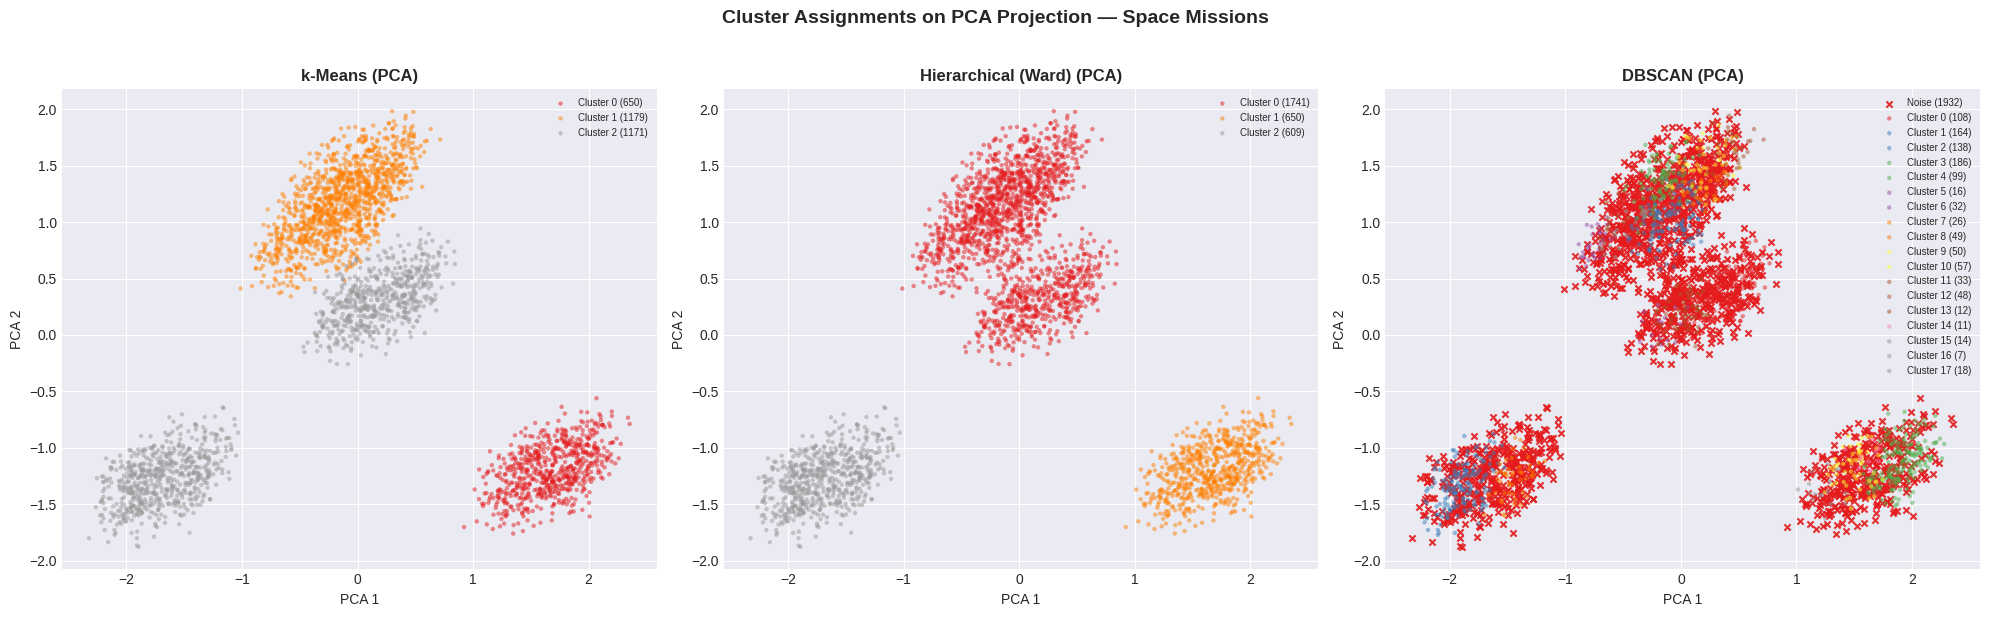

Saved → datasets/clustering_pca_comparison.png


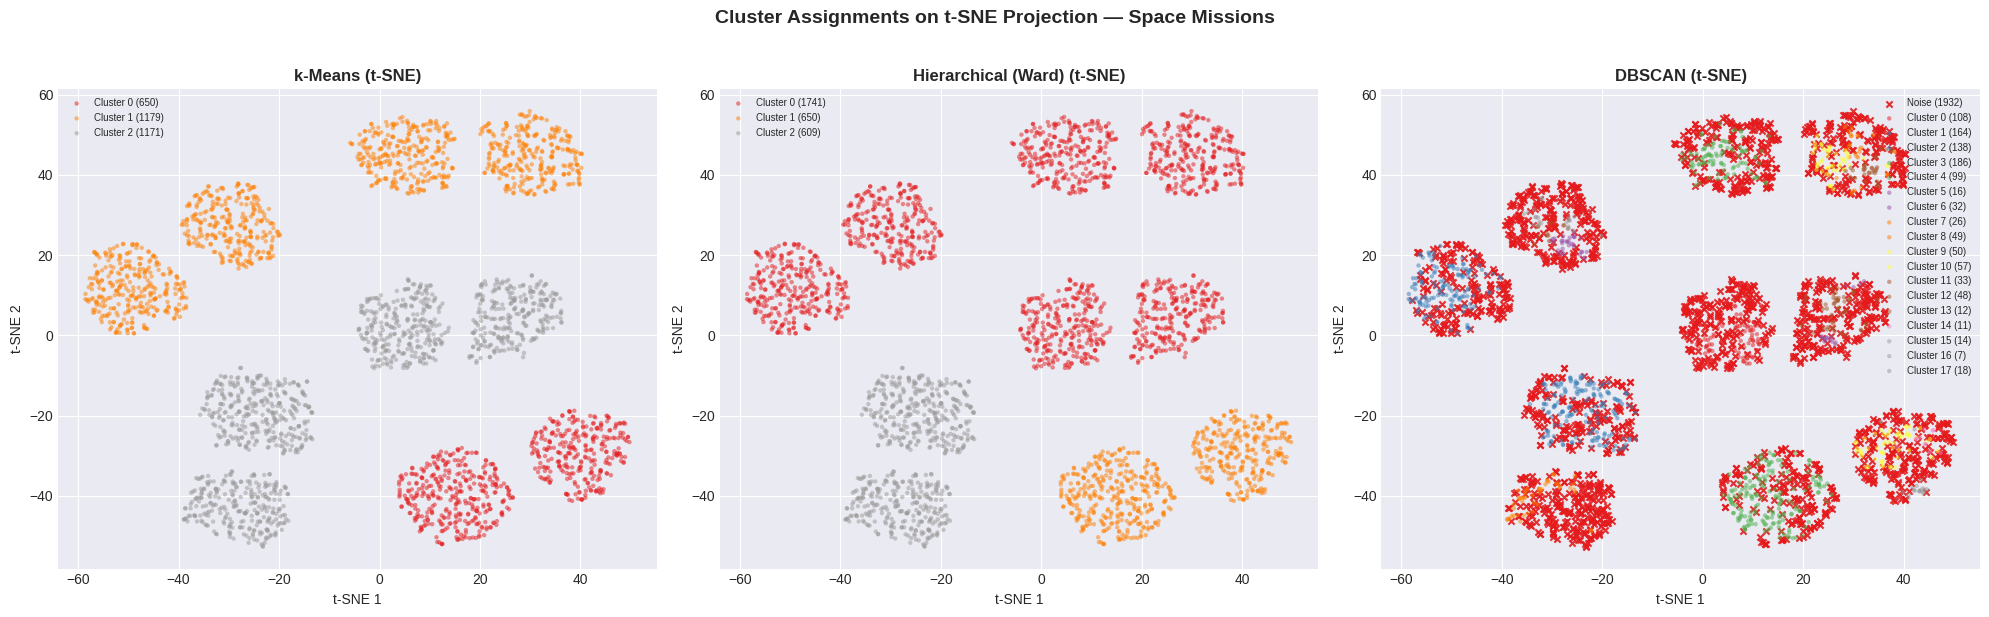

Saved → datasets/clustering_tsne_comparison.png


In [ ]:
def plot_clusters(X_emb, all_labels, titles, proj_name, save_path):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, labels, title in zip(axes, all_labels, titles):
        unique_lbl = sorted(set(labels))
        palette    = plt.cm.Set1(np.linspace(0, 1, len(unique_lbl)))
        for lbl, col in zip(unique_lbl, palette):
            mask      = labels == lbl
            lbl_name  = f'Noise ({mask.sum()})' if lbl == -1 else f'Cluster {lbl} ({mask.sum()})'
            marker    = 'x' if lbl == -1 else 'o'
            s, alpha  = (20, 0.9) if lbl == -1 else (10, 0.5)
            ax.scatter(X_emb[mask, 0], X_emb[mask, 1],
                       c=[col], label=lbl_name,
                       alpha=alpha, s=s, marker=marker, edgecolors='none')
        ax.set_title(f'{title} ({proj_name})', fontsize=12, fontweight='bold')
        ax.set_xlabel(f'{proj_name} 1')
        ax.set_ylabel(f'{proj_name} 2')
        ax.legend(fontsize=7, loc='best')
    fig.suptitle(f'Cluster Assignments on {proj_name} Projection — Space Missions',
                 fontsize=14, fontweight='bold', y=1.02)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {save_path}")

all_labels = [km_labels, agg_labels, db_labels]
titles     = ['k-Means', 'Hierarchical (Ward)', 'DBSCAN']

plot_clusters(X_pca,  all_labels, titles, 'PCA',  'datasets/clustering_pca_comparison.png')
plot_clusters(X_tsne, all_labels, titles, 't-SNE','datasets/clustering_tsne_comparison.png')


## Step 8 — Comparative Summary & Interpretation

**Silhouette Score ∈ [−1, 1]**

| Range | Interpretation |
|---|---|
| > 0.70 | Strong cluster structure |
| 0.50 – 0.70 | Reasonable structure |
| 0.25 – 0.50 | Weak structure |
| < 0.25 | No substantial structure |

**Adjusted Rand Index (ARI) ∈ [−0.5, 1]** — agreement with ground truth `is_high_success`.  
We do *not* expect a high ARI: unsupervised clustering finds natural structure, not supervised labels.  
A moderate ARI suggests the clusters partially align with the binary success definition.


In [ ]:
# DBSCAN silhouette (non-noise points only)
non_noise_mask = db_labels != -1
if n_clusters_db > 1 and non_noise_mask.sum() > 0:
    db_sil = silhouette_score(X_cluster[non_noise_mask], db_labels[non_noise_mask],
                              sample_size=min(1000, non_noise_mask.sum()))
else:
    db_sil = float('nan')

summary = {
    'k-Means (k=3)': {
        'Clusters Found':      OPTIMAL_K,
        'Noise Points':        0,
        'Silhouette Score':    round(km_sil, 4),
        'Adj. Rand Index':     round(km_ari, 4),
    },
    'Hierarchical (Ward)': {
        'Clusters Found':      OPTIMAL_K,
        'Noise Points':        0,
        'Silhouette Score':    round(agg_sil, 4),
        'Adj. Rand Index':     round(agg_ari, 4),
    },
    'DBSCAN': {
        'Clusters Found':      n_clusters_db,
        'Noise Points':        n_noise,
        'Silhouette Score':    round(db_sil, 4) if not np.isnan(db_sil) else 'N/A',
        'Adj. Rand Index':     round(adjusted_rand_score(y_cluster, db_labels), 4),
    },
}

summary_df = pd.DataFrame(summary).T
display(summary_df)
summary_df.to_csv("datasets/clustering_metrics.csv")
print("Saved → datasets/clustering_metrics.csv")


,Clusters Found,Noise Points,Silhouette Score,Adj. Rand Index
k-Means (k=3),3.0,0.0,0.1577,-0.0005
Hierarchical (Ward),3.0,0.0,0.1567,0.0008
DBSCAN,18.0,1932.0,0.1310,-0.0050


Saved → datasets/clustering_metrics.csv


In [ ]:
print("""
ALGORITHM COMPARISON FOR SPACE MISSION PROFILING
================================================
k-Means (k=3)
  Finds 3 broad archetypes, e.g.:
    Cluster 0 — Budget-Constrained Explorers (low funding, short duration, solo)
    Cluster 1 — Mid-Range Research Programmes (moderate budget, extended duration)
    Cluster 2 — High-Tech Flagship Missions   (AI/reusable tech, many partners)
  Fast; assumes spherical clusters; assigns EVERY mission to a cluster.

Hierarchical (Ward)
  The dendrogram reveals HOW groups relate to each other.
  A large jump in Ward distance = a meaningful boundary between mission types.
  Useful for asking: are 'budget' and 'duration' clusters independently structured?

DBSCAN
  The ONLY algorithm that explicitly labels outlier missions (label −1).
  These are missions with no historical precedent — unusual budget × duration ×
  technology combinations that deserve special mission-review board attention.
  In planning: 'this proposed configuration has NO precedent in our database.'
""")
print("\n✅  MODULE 5 COMPLETE")



ALGORITHM COMPARISON FOR SPACE MISSION PROFILING
k-Means (k=3)
  Finds 3 broad archetypes, e.g.:
    Cluster 0 — Budget-Constrained Explorers (low funding, short duration, solo)
    Cluster 1 — Mid-Range Research Programmes (moderate budget, extended duration)
    Cluster 2 — High-Tech Flagship Missions   (AI/reusable tech, many partners)
  Fast; assumes spherical clusters; assigns EVERY mission to a cluster.

Hierarchical (Ward)
  The dendrogram reveals HOW groups relate to each other.
  A large jump in Ward distance = a meaningful boundary between mission types.
  Useful for asking: are 'budget' and 'duration' clusters independently structured?

DBSCAN
  The ONLY algorithm that explicitly labels outlier missions (label −1).
  These are missions with no historical precedent — unusual budget × duration ×
  technology combinations that deserve special mission-review board attention.
  In planning: 'this proposed configuration has NO precedent in our database.'


✅  MODULE 5 COMPLETE
